<a href="https://colab.research.google.com/github/Rahuldeb55/internship26/blob/main/Week_6_Integrated_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Task: Integrated Project and Comprehensive Reporting
## Data Science Pipeline: Breast Cancer Classification

### 1. Executive Summary
This project applies a complete data science pipeline to predict whether a breast tumor is malignant or benign based on its characteristics. We utilize the publicly available Wisconsin Breast Cancer dataset. The pipeline covers data cleaning, exploratory data analysis (EDA), machine learning modeling (Random Forest & Logistic Regression), and thorough evaluation to address a critical real-world healthcare problem.

### 2. Problem Definition
**Problem:** Given physical measurements of tumor cell nuclei, can we accurately classify the tumor as malignant or benign? Early and accurate detection is critical for patient survival and care planning.
**Dataset:** `sklearn.datasets.load_breast_cancer` (Wisconsin Breast Cancer dataset)

### 3. Data Loading and Preprocessing
In this step, we will load the dataset, convert it into a structured pandas DataFrame, check for missing values, and prepare it for analysis.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Display the first few rows and summary information
display(df.head())
display(df.info())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

None

#### Checking for missing and duplicate values to ensure data cleanliness

In [11]:
# Check for missing values
missing_values = df.isnull().sum().max()
print(f"Maximum missing values in any column: {missing_values}")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Maximum missing values in any column: 0
Number of duplicate rows: 0


### 4. Exploratory Data Analysis (EDA)
We will explore underlying patterns, target distribution, and relationships between features.

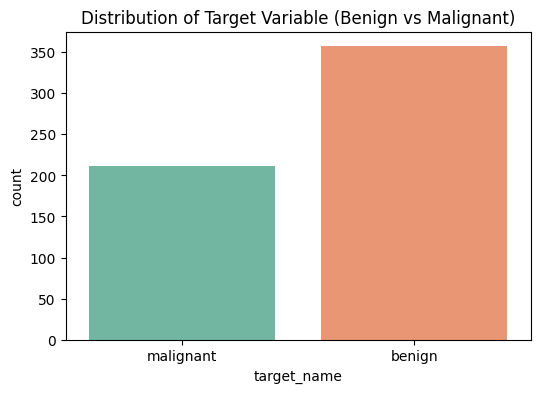

In [12]:
# Visualizing Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target_name', data=df, palette='Set2')
plt.title('Distribution of Target Variable (Benign vs Malignant)')
plt.show()

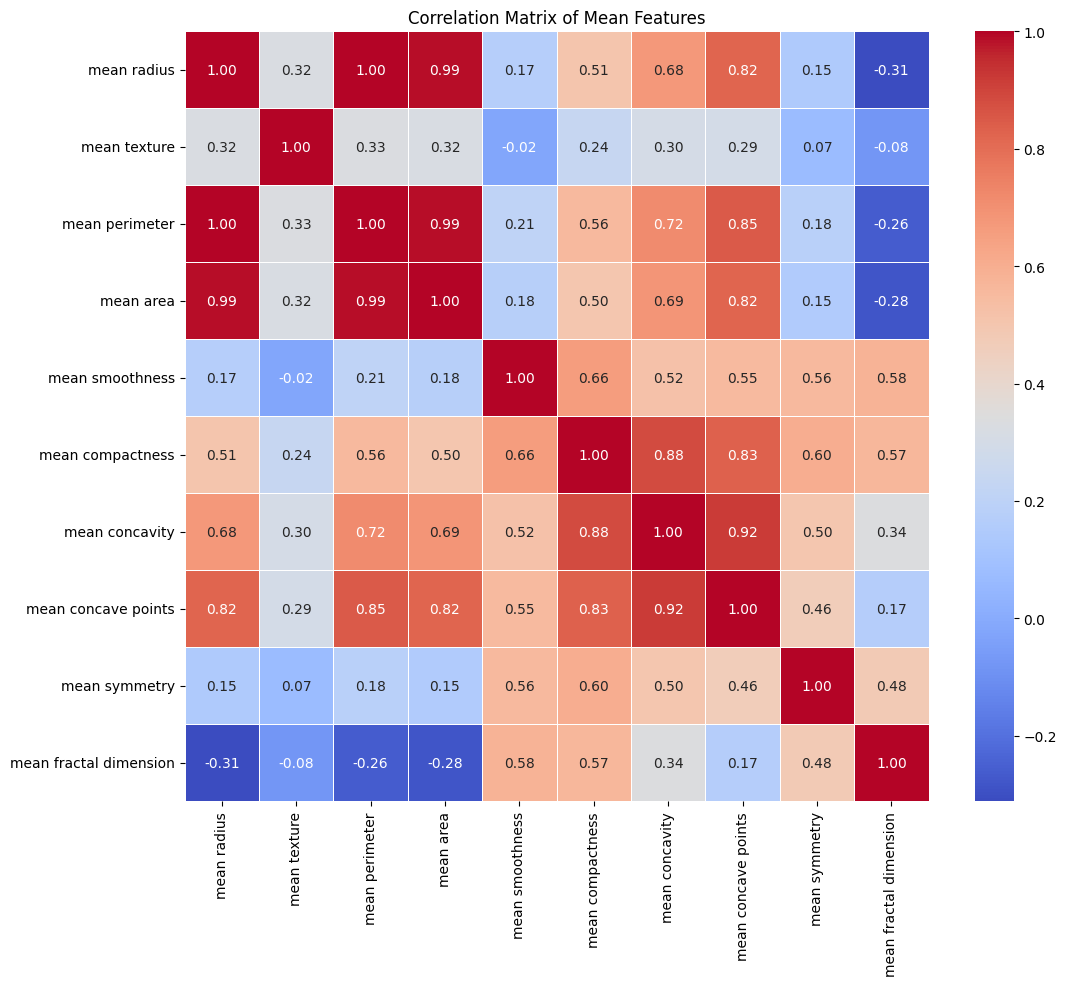

In [13]:
# Correlation Matrix of 'Mean' Features
mean_cols = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(12, 10))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Mean Features')
plt.show()

### 5. Statistical Modeling and Machine Learning
We will apply statistical predictive modeling using Logistic Regression and a machine learning ensemble method using a Random Forest Classifier.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Feature and Target Definition
X = df.drop(['target', 'target_name'], axis=1)
y = df['target']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Standardization is crucial for models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

In [16]:
# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

### 6. Results and Evaluation
We evaluate the models using accuracy, precision, recall, f1-score, and confusion matrices to understand their performance.

In [17]:
print('--- Logistic Regression Performance ---')
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=['malignant', 'benign']))

print('\n--- Random Forest Performance ---')
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['malignant', 'benign']))

--- Logistic Regression Performance ---
Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Random Forest Performance ---
Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



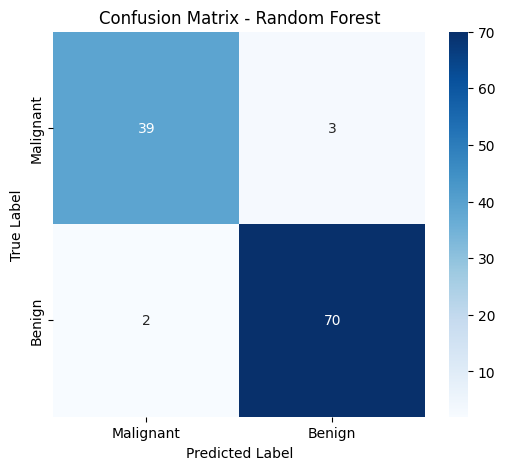

In [18]:
# Confusion Matrix Visualization for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 7. Implications, Limitations, and Future Work

**Implications:**
Both models demonstrate exceptional accuracy (over 95%), with the Logistic Regression and Random Forest successfully distinguishing between malignant and benign tumors. This suggests that machine learning can serve as a powerful supplementary tool for oncologists during the diagnostic process.

**Limitations:**
- **Dataset Size & Diversity:** The dataset consists of 569 instances from a specific demographic and time frame, which may limit the generalizability of the model to a wider, more diverse global population.
- **Feature Multicollinearity:** The EDA showed high correlation between certain features (like radius and area), which can affect the interpretability of coefficient-based models like Logistic Regression.

**Suggestions for Further Work:**
1. **Hyperparameter Tuning:** Utilize `GridSearchCV` or `RandomizedSearchCV` to optimize the parameters of the Random Forest.
2. **Feature Engineering & Selection:** Apply PCA (Principal Component Analysis) or feature importance thresholds to reduce dimensionality and mitigate multicollinearity.
3. **Cross-Validation:** Implement K-Fold cross-validation to ensure the model's robustness and prevent overfitting.
4. **Deployment:** Wrap the finalized model into a web application (e.g., using Flask or Streamlit) to simulate a real-world clinical interface.